# YOLOv11-Seg Training — Local / Tool Camera (Project 2)

**Model:** YOLOv11-Small Segmentation (`yolo11s-seg.pt`) — 10.1M parameters  
**Task:** Instance segmentation of 4 tool/screw classes  
**Camera:** Tool camera (close-up) — 640×640 px  
**Why segmentation:** Labels are already in YOLO polygon format — no conversion needed.

| Class | Description |
|---|---|
| `hole` | Empty screw hole in HDD body |
| `screw` | Full screw body outline |
| `screw_head` | Screw head only |
| `tool_head` | Screwdriver tip |

### Pipeline
1. Download dataset from Roboflow (polygon labels)
2. Split into 80/10/10 train/val/test — keep labels as-is
3. Train YOLOv11s-seg at 640×640
4. Plot training curves
5. Preview inference with segmentation masks

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 1: Download dataset and split into train/val/test
# Polygon labels are used directly — no bbox conversion needed for YOLO seg.
# ─────────────────────────────────────────────────────────────────────────────
from roboflow import Roboflow
import os
import random
import shutil
import yaml

rf = Roboflow(api_key="9X8ClVkM9agUJAH3hcAN")
project = rf.workspace("hard-drive").project("electronic_devices_local")
version = project.version(1)
dataset = version.download("yolov8")

DATA_PATH  = dataset.location        # e.g. Electronic_Devices_Local-1
OUTPUT_DIR = "dataset_yolo11_seg_640"

# Create split directory structure
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

for split in ["train", "valid", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, "labels"), exist_ok=True)

# All images live in train/ — shuffle and split 80/10/10
images_dir = os.path.join(DATA_PATH, "train", "images")
labels_dir = os.path.join(DATA_PATH, "train", "labels")

images = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(".jpg")])
random.seed(42)
random.shuffle(images)

train_idx = int(len(images) * 0.80)
val_idx   = int(len(images) * 0.90)
splits = {
    "train": images[:train_idx],
    "valid": images[train_idx:val_idx],
    "test":  images[val_idx:],
}

for split_name, img_list in splits.items():
    for img_name in img_list:
        # Copy image
        shutil.copy(
            os.path.join(images_dir, img_name),
            os.path.join(OUTPUT_DIR, split_name, "images", img_name),
        )
        # Copy polygon label AS-IS — YOLO seg uses the same format
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_src  = os.path.join(labels_dir, label_name)
        label_dst  = os.path.join(OUTPUT_DIR, split_name, "labels", label_name)
        if os.path.exists(label_src):
            shutil.copy(label_src, label_dst)
        else:
            # Create empty label for any unannotated image
            open(label_dst, "w").close()

# Write YOLO-format data.yaml
with open(os.path.join(DATA_PATH, "data.yaml"), "r") as fh:
    source_yaml = yaml.safe_load(fh)

data_yaml = {
    "path": os.path.abspath(OUTPUT_DIR),
    "train": "train/images",
    "val":   "valid/images",
    "test":  "test/images",
    "nc":    source_yaml["nc"],
    "names": source_yaml["names"],
}

yaml_path = os.path.join(OUTPUT_DIR, "data.yaml")
with open(yaml_path, "w") as fh:
    yaml.dump(data_yaml, fh, default_flow_style=False, sort_keys=False)

print(f"✅ Dataset split complete ({OUTPUT_DIR}/)")
print(f"   train: {len(splits['train'])}  val: {len(splits['valid'])}  test: {len(splits['test'])}")
print(f"   Classes ({data_yaml['nc']}): {data_yaml['names']}")
print(f"   data.yaml → {os.path.abspath(yaml_path)}")

loading Roboflow workspace...
loading Roboflow project...
✅ Dataset split complete (dataset_yolo11_seg_640/)
   train: 2240  val: 280  test: 280
   Classes (4): ['hole', 'screw', 'screw_head', 'tool_head']
   data.yaml → /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 2 (Tool-Screw)/rfdetr/dataset_yolo11_seg_640/data.yaml


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 2: Validate dataset — verify polygon labels are intact
# ─────────────────────────────────────────────────────────────────────────────
import glob
import numpy as np

label_files = glob.glob(os.path.join(OUTPUT_DIR, "train", "labels", "*.txt"))
issues = []
class_counts = {}
vertex_counts = []

for lf in label_files:
    with open(lf) as fh:
        for lineno, line in enumerate(fh, 1):
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 7:   # class + at least 3 (x,y) pairs = 7 tokens minimum
                issues.append(f"{os.path.basename(lf)}:{lineno} — too few coords ({len(parts)} tokens)")
                continue
            cls = int(parts[0])
            class_counts[cls] = class_counts.get(cls, 0) + 1
            coords = list(map(float, parts[1:]))
            if len(coords) % 2 != 0:
                issues.append(f"{os.path.basename(lf)}:{lineno} — odd coord count ({len(coords)})")
            else:
                vertex_counts.append(len(coords) // 2)
                out_of_range = [v for v in coords if not (0.0 <= v <= 1.0)]
                if out_of_range:
                    issues.append(f"{os.path.basename(lf)}:{lineno} — coords out of [0,1]: {out_of_range[:4]}")

print(f"Label files checked : {len(label_files)}")
print(f"Total annotations   : {sum(class_counts.values())}")
if vertex_counts:
    print(f"Avg polygon vertices: {np.mean(vertex_counts):.1f}  (min={min(vertex_counts)}, max={max(vertex_counts)})")
print(f"Issues found        : {len(issues)}")

with open(yaml_path) as fh:
    cfg = yaml.safe_load(fh)
class_names = cfg["names"]

print("\nClass distribution in train:")
for cls_id, count in sorted(class_counts.items()):
    name = class_names[cls_id] if cls_id < len(class_names) else f"class_{cls_id}"
    pct  = 100 * count / max(sum(class_counts.values()), 1)
    print(f"  [{cls_id}] {name:<15}: {count:>5}  ({pct:.1f}%)")

if issues:
    print("\n⚠️ Issues:")
    for i in issues[:10]:
        print(f"  {i}")
else:
    print("\n✅ All labels are valid YOLO segmentation format")

Label files checked : 2240
Total annotations   : 7773
Avg polygon vertices: 43.7  (min=7, max=129)
Issues found        : 0

Class distribution in train:
  [0] hole           :   748  (9.6%)
  [1] screw          :  2704  (34.8%)
  [2] screw_head     :  2087  (26.8%)
  [3] tool_head      :  2234  (28.7%)

✅ All labels are valid YOLO segmentation format


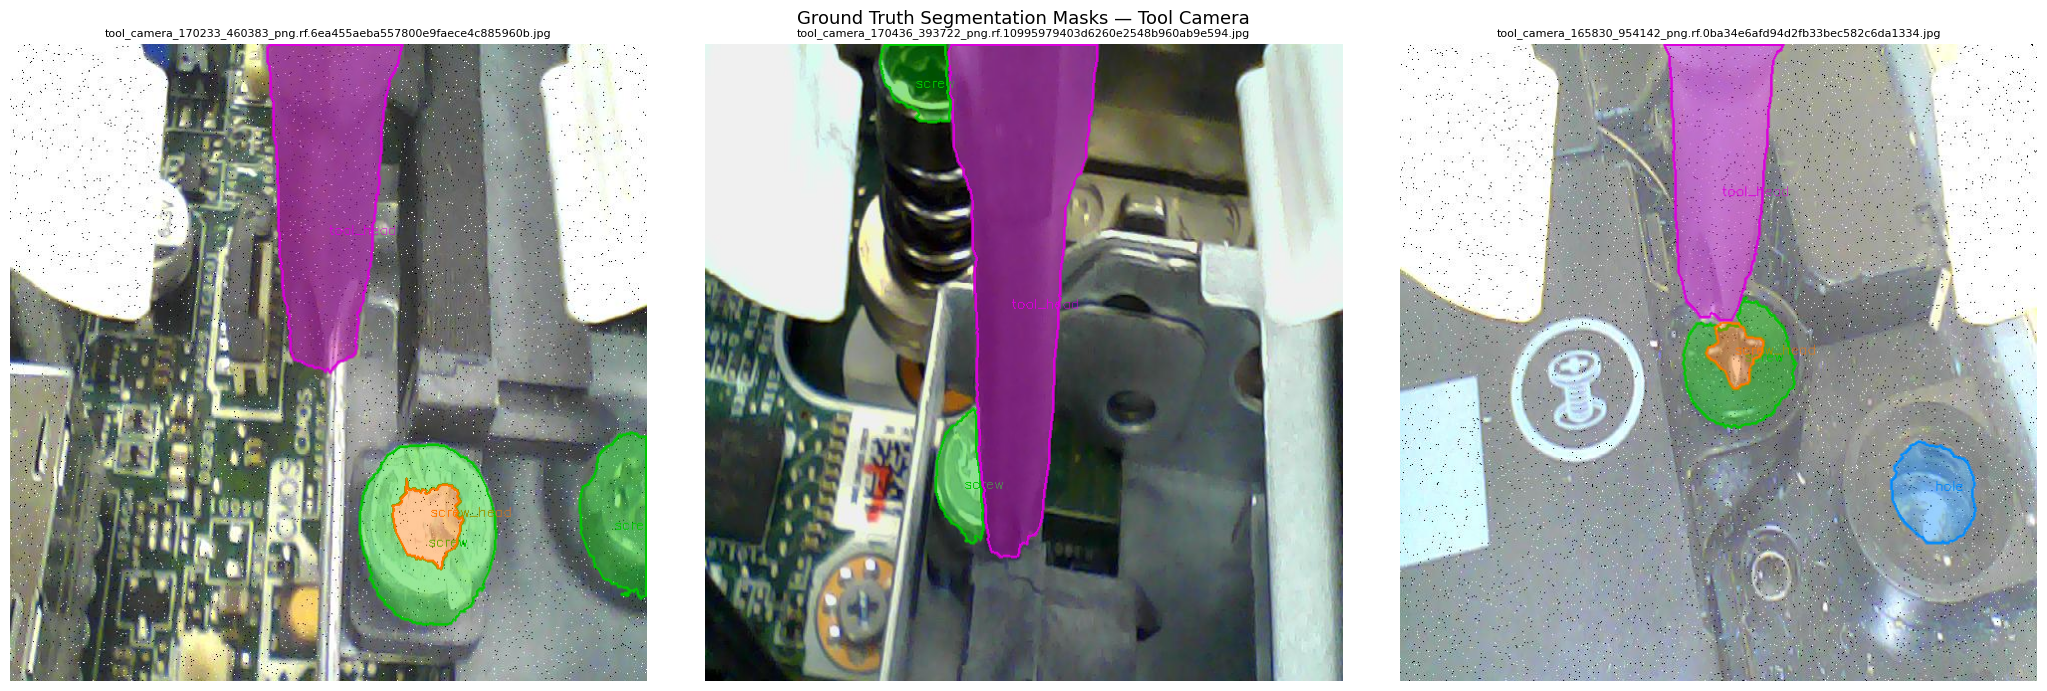

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 3: Preview ground-truth segmentation masks
# ─────────────────────────────────────────────────────────────────────────────
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random

# Class colours (fixed for reproducibility)
CLASS_COLORS = {
    0: (255, 140,   0),   # hole       — orange
    1: (  0, 200,   0),   # screw      — green
    2: (  0, 120, 255),   # screw_head — blue
    3: (220,   0, 220),   # tool_head  — magenta
}

train_imgs = sorted(glob.glob(os.path.join(OUTPUT_DIR, "train", "images", "*.jpg")))
sample     = random.sample(train_imgs, min(3, len(train_imgs)))

fig, axes = plt.subplots(1, len(sample), figsize=(7 * len(sample), 7))
if len(sample) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample):
    lbl_path = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")
    img      = cv2.imread(img_path)
    H, W     = img.shape[:2]
    overlay  = img.copy()

    if os.path.exists(lbl_path):
        with open(lbl_path) as fh:
            for line in fh:
                parts = line.strip().split()
                if len(parts) < 7:
                    continue
                cls    = int(parts[0])
                coords = list(map(float, parts[1:]))
                pts    = np.array([[coords[i]*W, coords[i+1]*H]
                                   for i in range(0, len(coords), 2)],
                                  dtype=np.int32).reshape((-1, 1, 2))
                color  = CLASS_COLORS.get(cls, (180, 180, 180))
                cv2.fillPoly(overlay, [pts], color)
                cv2.polylines(img, [pts], True, color, 2)
                cx = int(pts[:, 0, 0].mean())
                cy = int(pts[:, 0, 1].mean())
                name = class_names[cls] if cls < len(class_names) else str(cls)
                cv2.putText(img, name, (cx, cy),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    vis = cv2.addWeighted(overlay, 0.40, img, 0.60, 0)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.axis("off")
    ax.set_title(os.path.basename(img_path), fontsize=8)

plt.suptitle("Ground Truth Segmentation Masks — Tool Camera", fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 4: Train YOLOv11s-seg
#
# Hardware target: RTX 4070 Laptop GPU (8 GB VRAM)
#   imgsz=640    → native 640×640 tool camera resolution
#   batch=16     → larger batch OK for Small model at 640
#   workers=8    → saturate CPU-side data loading
#   epochs=150   → model was still improving at ep100 (mAP50-95 climbing +0.015
#                  over last 25 epochs); extended to squeeze more mask precision
#   patience=25  → wider window — gains are small but consistent past ep75
#
# Note: YOLO writes output to <project>/<name>/.
#   project="runs"  name="yolo11s_seg_640"  →  runs/yolo11s_seg_640/
#   exist_ok=True allows re-running into the same directory without errors.
# ─────────────────────────────────────────────────────────────────────────────
from ultralytics import YOLO

RUN_NAME = "yolo11s_seg_640"
RUN_DIR  = os.path.join("runs", RUN_NAME)          # actual output directory

model = YOLO("yolo11s-seg.pt")   # COCO-pretrained Small segmentation weights

results = model.train(
    data      = os.path.abspath(yaml_path),
    epochs    = 150,             # extended: was 100, mAP50-95 still climbing
    imgsz     = 640,
    batch     = 16,
    workers   = 8,
    patience  = 25,              # extended: was 20, gains are slow but real
    optimizer = "AdamW",
    lr0       = 0.001,
    lrf       = 0.01,
    momentum  = 0.937,
    weight_decay = 0.0005,
    # Augmentation — appropriate for close-up tool camera
    hsv_h     = 0.010,
    hsv_s     = 0.5,
    hsv_v     = 0.3,
    degrees   = 5.0,
    translate = 0.05,
    scale     = 0.4,
    fliplr    = 0.5,
    mosaic    = 0.5,             # lower mosaic for close-up tool images
    close_mosaic = 10,
    # Output location
    project   = "runs",
    name      = RUN_NAME,
    exist_ok  = True,            # resume into same directory if re-running
    save      = True,
    plots     = True,
    verbose   = True,
)

print(f"\n✅ Training complete. Results saved to: {RUN_DIR}/")
print(f"   Best weights: {RUN_DIR}/weights/best.pt")

New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.46 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7806MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 2 (Tool-Screw)/rfdetr/dataset_yolo11_seg_640/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1871.0±822.1 MB/s, size: 76.6 KB)
val: Scanning /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 2 (Tool-Screw)/rfdetr/dataset_yolo11_seg_640/valid/labels... 280 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 280/280 1.9Kit/s 0.1s<0.2s
val: New cache created: /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 2 (Tool-Screw)/rfdetr/dataset_yolo11_seg_640/valid/labels.cache
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 90 weight(decay=0.0), 101 weight(decay=0.0005), 100 bias(decay=0.0)
Plotting labels to /home/adip/workspace/disassembly_ws/src/runs/segment/runs/yolo11s_seg_640/labels.jpg... 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/adip/workspace/disassembly_ws/src/runs/segment/runs/yolo11s_seg_640
Starting training for 150 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 5: Parse YOLO CSV results and report best metrics
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd

csv_path = os.path.join(RUN_DIR, "results.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    print("Available metric columns:")
    print([c for c in df.columns])

    for col in ["metrics/mAP50(M)", "metrics/mAP50-95(M)", "metrics/mAP50(B)"]:
        if col in df.columns:
            best_val = df[col].max()
            best_ep  = int(df[col].idxmax()) + 1
            print(f"\n🏆 Best {col}: {best_val:.4f}  (epoch {best_ep})")
else:
    print(f"❌ {csv_path} not found — run training cell first.")

Available metric columns:
['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'train/sem_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'val/sem_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

🏆 Best metrics/mAP50(M): 0.9950  (epoch 65)

🏆 Best metrics/mAP50-95(M): 0.9022  (epoch 99)

🏆 Best metrics/mAP50(B): 0.9950  (epoch 65)


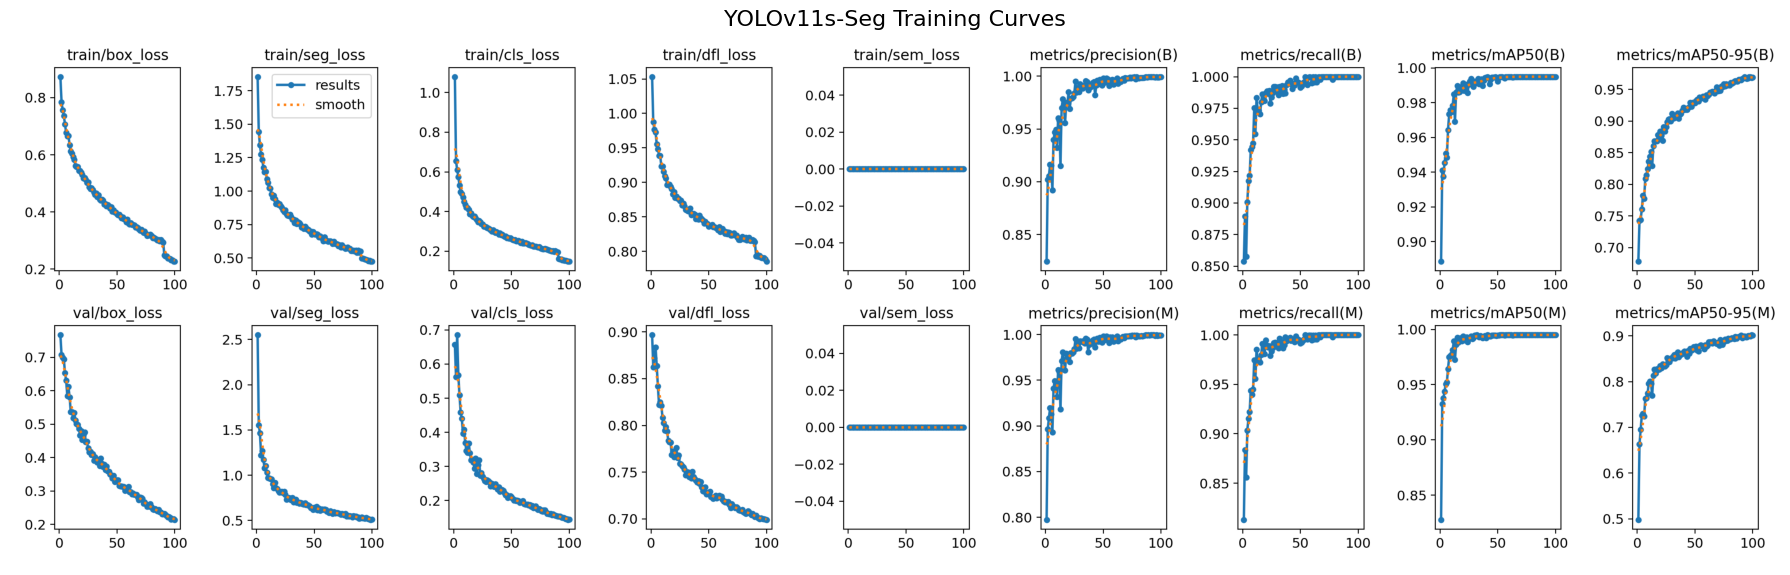

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6: Show YOLO auto-generated training curves image
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plot_path = os.path.join(RUN_DIR, "results.png")

if os.path.exists(plot_path):
    plt.figure(figsize=(18, 10))
    img = mpimg.imread(plot_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title("YOLOv11s-Seg Training Curves", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ {plot_path} not found — training plots are generated automatically.")

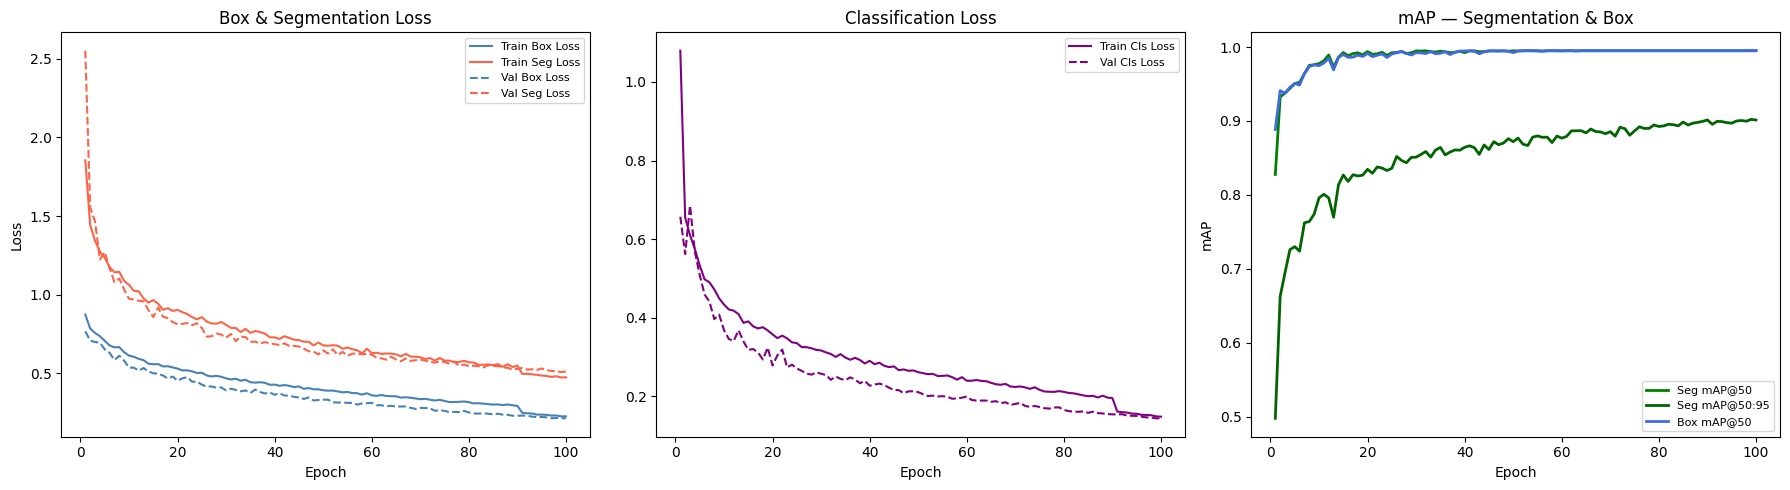

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7: Custom metric plots from results.csv
# ─────────────────────────────────────────────────────────────────────────────
if "df" in dir() and not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # — Box + Seg losses —
    ax = axes[0]
    for col, label, color in [
        ("train/box_loss", "Train Box Loss", "steelblue"),
        ("train/seg_loss", "Train Seg Loss", "tomato"),
        ("val/box_loss",   "Val Box Loss",   "steelblue"),
        ("val/seg_loss",   "Val Seg Loss",   "tomato"),
    ]:
        if col in df.columns:
            style = "--" if col.startswith("val") else "-"
            ax.plot(df["epoch"], df[col], label=label, linestyle=style, color=color)
    ax.set_title("Box & Segmentation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)

    # — Classification loss —
    ax = axes[1]
    for col, label, color in [
        ("train/cls_loss", "Train Cls Loss", "purple"),
        ("val/cls_loss",   "Val Cls Loss",   "purple"),
    ]:
        if col in df.columns:
            style = "--" if col.startswith("val") else "-"
            ax.plot(df["epoch"], df[col], label=label, linestyle=style, color=color)
    ax.set_title("Classification Loss")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)

    # — mAP curves —
    ax = axes[2]
    for col, label, color in [
        ("metrics/mAP50(M)",    "Seg mAP@50",    "green"),
        ("metrics/mAP50-95(M)", "Seg mAP@50:95", "darkgreen"),
        ("metrics/mAP50(B)",    "Box mAP@50",    "royalblue"),
    ]:
        if col in df.columns:
            ax.plot(df["epoch"], df[col], label=label, color=color, linewidth=2)
    ax.set_title("mAP — Segmentation & Box")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("❌ Run Cell 5 (parse results) before plotting.")

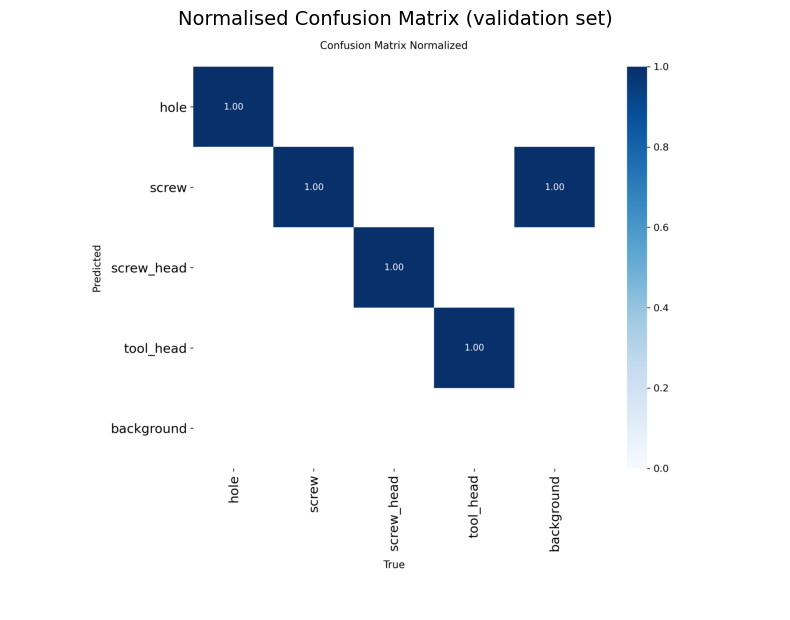

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 8: Show confusion matrix (auto-generated by YOLO)
# ─────────────────────────────────────────────────────────────────────────────
cm_path = os.path.join(RUN_DIR, "confusion_matrix_normalized.png")

if os.path.exists(cm_path):
    plt.figure(figsize=(8, 7))
    img = mpimg.imread(cm_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Normalised Confusion Matrix (validation set)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ {cm_path} not found — generated after val run.")

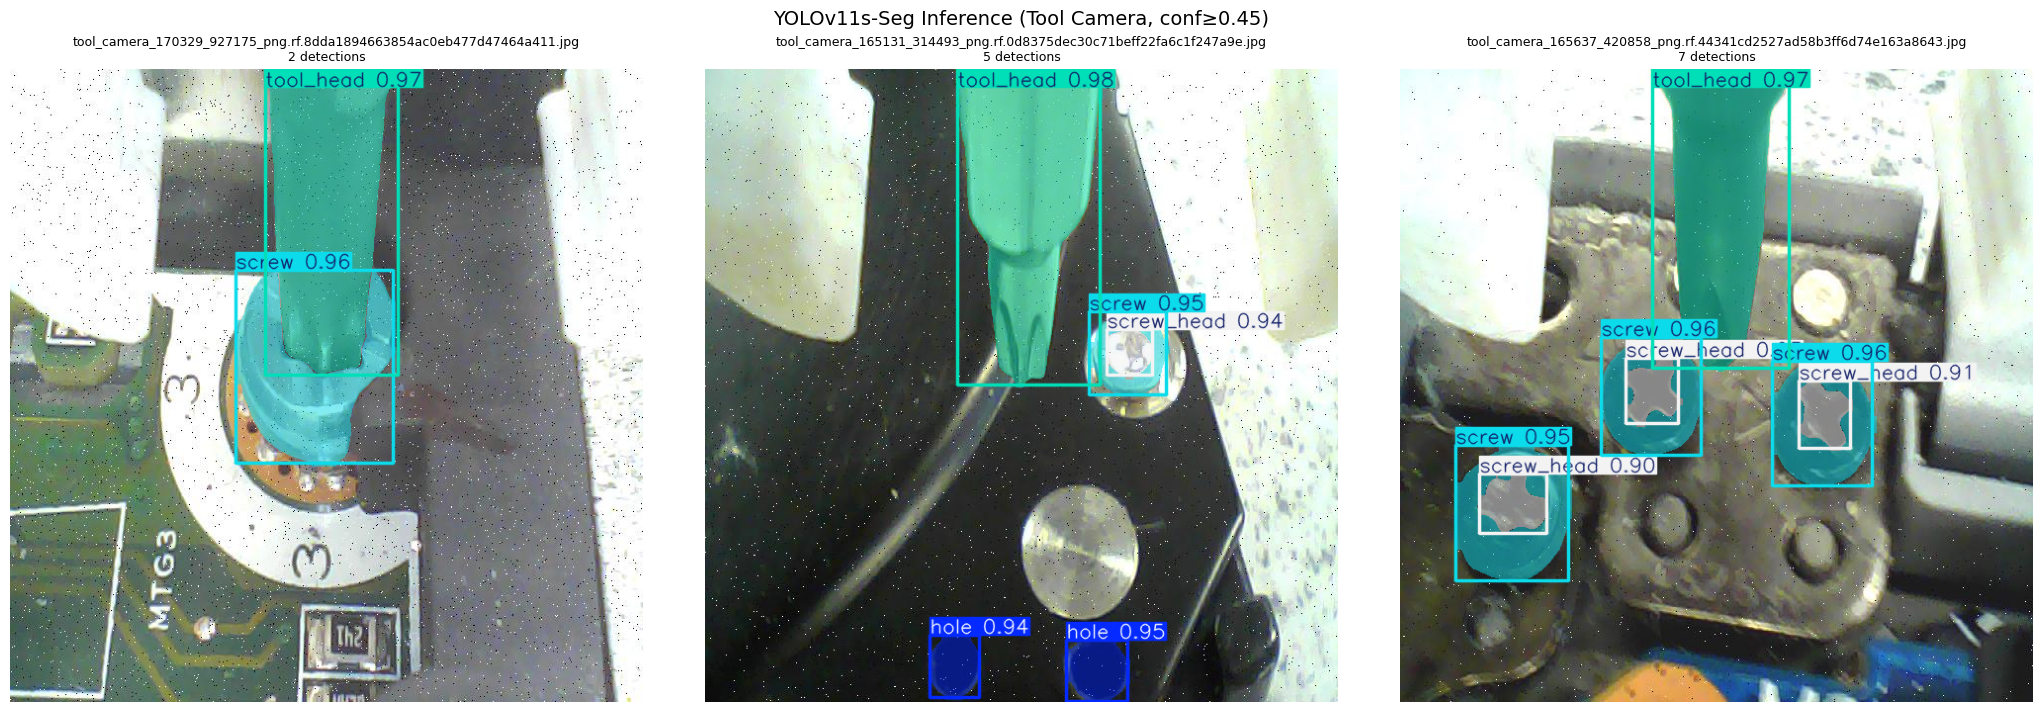

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 9: Inference preview — segmentation masks on 3 test images
# ─────────────────────────────────────────────────────────────────────────────
from ultralytics import YOLO
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

best_weights = os.path.join(RUN_DIR, "weights", "best.pt")
if not os.path.exists(best_weights):
    raise FileNotFoundError(f"Weights not found: {best_weights}. Run training first.")

model_inf = YOLO(best_weights)

test_imgs = sorted(glob.glob(os.path.join(OUTPUT_DIR, "test", "images", "*.jpg")))
sample    = random.sample(test_imgs, min(3, len(test_imgs)))

fig, axes = plt.subplots(1, len(sample), figsize=(7 * len(sample), 7))
if len(sample) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample):
    results = model_inf.predict(
        source  = img_path,
        conf    = 0.45,
        iou     = 0.45,
        imgsz   = 640,
        verbose = False,
    )
    result = results[0]
    vis    = result.plot(labels=True, conf=True, masks=True, boxes=True)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.axis("off")
    n_det = len(result.boxes) if result.boxes is not None else 0
    ax.set_title(f"{os.path.basename(img_path)}\n{n_det} detections", fontsize=9)

plt.suptitle("YOLOv11s-Seg Inference (Tool Camera, conf≥0.45)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 10: Evaluate on test split — full COCO metrics per-class
# ─────────────────────────────────────────────────────────────────────────────
from ultralytics import YOLO

best_weights = os.path.join(RUN_DIR, "weights", "best.pt")
model_eval   = YOLO(best_weights)

metrics = model_eval.val(
    data   = os.path.abspath(yaml_path),
    split  = "test",
    imgsz  = 640,
    conf   = 0.001,
    iou    = 0.6,
    verbose= True,
)

print("\n══════════════════════════════════════")
print("  TEST SET EVALUATION — YOLOv11s-Seg")
print("══════════════════════════════════════")
print(f"  Box  mAP@50    : {metrics.box.map50:.4f}")
print(f"  Box  mAP@50:95 : {metrics.box.map:.4f}")
print(f"  Mask mAP@50    : {metrics.seg.map50:.4f}")
print(f"  Mask mAP@50:95 : {metrics.seg.map:.4f}")
print("══════════════════════════════════════")

# Per-class breakdown
print("\nPer-class Mask mAP@50:")
with open(yaml_path) as fh:
    cnames = yaml.safe_load(fh)["names"]
for i, (name, ap50) in enumerate(zip(cnames, metrics.seg.ap50)):
    print(f"  [{i}] {name:<15}: {ap50:.4f}")

Ultralytics 8.4.46 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7806MiB)
YOLO11s-seg summary (fused): 114 layers, 10,068,364 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3926.7±743.0 MB/s, size: 68.0 KB)
val: Scanning /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 2 (Tool-Screw)/rfdetr/dataset_yolo11_seg_640/test/labels... 280 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 280/280 2.5Kit/s 0.1s<0.1s
val: New cache created: /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 2 (Tool-Screw)/rfdetr/dataset_yolo11_seg_640/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 6.0it/s 3.0s0.1s
                   all        280        972      0.999      0.998      0.995      0.969      0.999      0.998      0.995      0.892

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 11: Export best model to ONNX and deploy to local_model/
#
# Deployment target (relative to this notebook's directory):
#   vision_training/Project 2 (Tool-Screw)/rfdetr/local_model/
# ─────────────────────────────────────────────────────────────────────────────
import shutil
from ultralytics import YOLO

# Resolve local_model/ relative to the notebook's working directory (rfdetr/)
LOCAL_MODEL_DIR = os.path.abspath("local_model")
os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)

best_weights = "/home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 2 (Tool-Screw)/rfdetr/runs/yolo11s_seg_640/weights/best.pt"
model_export = YOLO(best_weights)

# ── Export to ONNX ──
onnx_path = model_export.export(
    format  = "onnx",
    imgsz   = 640,
    dynamic = True,
    opset   = 17,
    simplify= True,
)
print(f"✅ ONNX exported  : {onnx_path}")

# ── Copy best.pt and ONNX into local_model/ ──
dst_pt   = os.path.join(LOCAL_MODEL_DIR, "best.pt")
dst_onnx = os.path.join(LOCAL_MODEL_DIR, "best.onnx")

shutil.copy2(best_weights, dst_pt)
shutil.copy2(str(onnx_path), dst_onnx)

print(f"✅ Deployed best.pt   → {dst_pt}")
print(f"✅ Deployed best.onnx → {dst_onnx}")
print(f"\nlocal_model/ contents:")
for f in sorted(os.listdir(LOCAL_MODEL_DIR)):
    size_mb = os.path.getsize(os.path.join(LOCAL_MODEL_DIR, f)) / 1e6
    print(f"  {f}  ({size_mb:.1f} MB)")

Ultralytics 8.4.46 🚀 Python-3.10.12 torch-2.10.0+cu128 CPU (Intel Core i7-14700HX)


YOLO11s-seg summary (fused): 114 layers, 10,068,364 parameters, 0 gradients, 32.8 GFLOPs

PyTorch: starting from '/home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 2 (Tool-Screw)/rfdetr/runs/yolo11s_seg_640/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 40, 8400), (1, 32, 160, 160)) (19.6 MB)

ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.4s, saved as '/home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 2 (Tool-Screw)/rfdetr/runs/yolo11s_seg_640/weights/best.onnx' (39.2 MB)

Export complete (1.7s)
Results saved to /home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 2 (Tool-Screw)/rfdetr/runs/yolo11s_seg_640/weights/best.onnx
Predict:         yolo predict task=segment model=/home/adip/workspace/disassembly_ws/src/agentic_disassembly/vision_training/Project 2 (Tool-Screw)/rfdetr/runs/yolo11

: 